Cell 1: Imports

In [7]:
import os
import json
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

Cell 2: Paths

In [8]:
DATASET_ROOT = Path("D:/Judy Uni/archive/PVDN")
INDEX_DIR = Path("outputs")

PATCH_OUTPUT_DIR = Path("patch_dataset")
PATCH_OUTPUT_DIR.mkdir(exist_ok=True)

PATCH_IMAGE_DIR = PATCH_OUTPUT_DIR / "images"
PATCH_IMAGE_DIR.mkdir(exist_ok=True)

PATCH_CSV_PATH = PATCH_OUTPUT_DIR / "patch_index.csv"

print("Dataset root exists:", DATASET_ROOT.exists())
print("Patch output:", PATCH_OUTPUT_DIR.resolve())

Dataset root exists: True
Patch output: D:\Judy Uni\archive\patch_dataset


Cell 3: Load existing indexes

In [9]:
train_df = pd.read_csv(INDEX_DIR / "train_index.csv")
val_df = pd.read_csv(INDEX_DIR / "val_index.csv")
test_df = pd.read_csv(INDEX_DIR / "test_index.csv")

full_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print("Full size:", len(full_df))
full_df.head()

Full size: 33638


,split,image_path,annotation_path,image_filename,sequence_folder,image_id,has_vehicle,has_visible_vehicle,has_hidden_vehicle,num_vehicles,...,num_rear_reflections,has_oncoming_reflection,has_reflection_only_signal,vehicle_positions,direct_light_positions,reflection_positions,reflection_only_instances,reflection_density,label_reflection_only,label_approaching_vehicle
0,train,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,000001.png,S00000,1,0,0,0,0,...,0,0,0,[],[],[],0,0.0,0,0
1,train,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,000003.png,S00000,3,0,0,0,0,...,0,0,0,[],[],[],0,0.0,0,0
2,train,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,000005.png,S00000,5,0,0,0,0,...,0,0,0,[],[],[],0,0.0,0,0
3,train,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,000007.png,S00000,7,0,0,0,0,...,0,0,0,[],[],[],0,0.0,0,0
4,train,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,000009.png,S00000,9,0,0,0,0,...,0,0,0,[],[],[],0,0.0,0,0


Cell 4: CLAHE

In [10]:
def apply_clahe(image):
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    return clahe.apply(image)

Cell 5: Patch Crop helper

In [11]:
PATCH_SIZE = 128
HALF_PATCH = PATCH_SIZE // 2


def crop_patch(image, x, y, patch_size=PATCH_SIZE):
    """
    Crops patch centered at x,y.
    Pads image if patch goes outside boundaries.
    """
    
    h, w = image.shape
    
    x = int(x)
    y = int(y)
    
    half = patch_size // 2
    
    x1 = x - half
    y1 = y - half
    x2 = x + half
    y2 = y + half
    
    pad_left = max(0, -x1)
    pad_top = max(0, -y1)
    pad_right = max(0, x2 - w)
    pad_bottom = max(0, y2 - h)
    
    if pad_left or pad_top or pad_right or pad_bottom:
        image = cv2.copyMakeBorder(
            image,
            pad_top,
            pad_bottom,
            pad_left,
            pad_right,
            cv2.BORDER_REFLECT
        )
        x1 += pad_left
        x2 += pad_left
        y1 += pad_top
        y2 += pad_top
    
    patch = image[y1:y2, x1:x2]
    
    return patch

Cell 6: Parse annotations positions

In [12]:
def get_oncoming_reflection_points(annotation_path):
    """
    Positive points:
    instance["direct"] == False
    instance["rear"] == False
    """
    
    with open(annotation_path, "r") as f:
        data = json.load(f)
    
    points = []
    
    for vehicle in data.get("annotations", []):
        
        for instance in vehicle.get("instances", []):
            
            is_reflection = instance["direct"] == False
            is_oncoming = instance["rear"] == False
            
            if is_reflection and is_oncoming:
                x, y = instance["pos"]
                points.append((x, y))
    
    return points

Cell 7: Negative point helper

In [13]:
def point_too_close(x, y, positive_points, min_distance=100):
    for px, py in positive_points:
        dist = np.sqrt((x - px) ** 2 + (y - py) ** 2)
        if dist < min_distance:
            return True
    return False


def sample_negative_points(image_shape, positive_points, num_samples=2):
    """
    Samples negatives from road/reflection-relevant area.
    Avoids positive reflection locations.
    """
    
    h, w = image_shape
    
    points = []
    attempts = 0
    
    while len(points) < num_samples and attempts < 100:
        attempts += 1
        
        # road-focused sampling
    
        x = random.randint(int(w * 0.20), int(w * 0.80))
        y = random.randint(int(h * 0.60), int(h * 0.88))
        
        if not point_too_close(x, y, positive_points):
            points.append((x, y))
    
    return points

Cell 8: Build patches

In [14]:
PATCH_OUTPUT_DIR.mkdir(exist_ok=True)
PATCH_IMAGE_DIR.mkdir(exist_ok=True)

In [15]:
rows = []

positive_count = 0
negative_count = 0

random.seed(42)

for idx, row in tqdm(full_df.iterrows(), total=len(full_df)):
    
    image_path = row["image_path"]
    annotation_path = row["annotation_path"]
    split = row["split"]
    
    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )
    
    if image is None:
        continue
    
    image = apply_clahe(image)
    
    positive_points = get_oncoming_reflection_points(annotation_path)
    
    # ------------------------------
    # POSITIVE PATCHES
    # ------------------------------
    for point_idx, (x, y) in enumerate(positive_points):
        
        patch = crop_patch(image, x, y)
        
        patch_filename = (
            f"{split}_pos_{idx}_{point_idx}.png"
        )
        
        patch_path = PATCH_IMAGE_DIR / patch_filename
        
        cv2.imwrite(str(patch_path), patch)
        
        rows.append({
            "patch_path": str(patch_path),
            "source_image_path": image_path,
            "annotation_path": annotation_path,
            "split": split,
            "label": 1,
            "center_x": x,
            "center_y": y,
            "patch_type": "positive_reflection"
        })
        
        positive_count += 1
    
    # ------------------------------
    # NEGATIVE PATCHES
    # ------------------------------
    # create negatives even for images with no reflections
    num_negatives = max(1, min(3, len(positive_points) + 1))
    
    negative_points = sample_negative_points(
        image.shape,
        positive_points,
        num_samples=num_negatives
    )
    
    for neg_idx, (x, y) in enumerate(negative_points):
        
        patch = crop_patch(image, x, y)
        
        patch_filename = (
            f"{split}_neg_{idx}_{neg_idx}.png"
        )
        
        patch_path = PATCH_IMAGE_DIR / patch_filename
        
        cv2.imwrite(str(patch_path), patch)
        
        rows.append({
            "patch_path": str(patch_path),
            "source_image_path": image_path,
            "annotation_path": annotation_path,
            "split": split,
            "label": 0,
            "center_x": x,
            "center_y": y,
            "patch_type": "negative_road"
        })
        
        negative_count += 1

patch_df = pd.DataFrame(rows)

print("Positive patches:", positive_count)
print("Negative patches:", negative_count)
print("Total patches:", len(patch_df))

  0%|          | 0/33638 [00:00<?, ?it/s]

100%|██████████| 33638/33638 [27:48<00:00, 20.16it/s]


Positive patches: 41836
Negative patches: 64716
Total patches: 106552


Cell 9: Save patch index

In [16]:
patch_df.to_csv(
    PATCH_CSV_PATH,
    index=False
)

print("Saved:", PATCH_CSV_PATH.resolve())

patch_df.head()

Saved: D:\Judy Uni\archive\patch_dataset\patch_index.csv


,patch_path,source_image_path,annotation_path,split,label,center_x,center_y,patch_type
0,patch_dataset\images\train_neg_0_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,910,633,negative_road
1,patch_dataset\images\train_neg_1_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,281,716,negative_road
2,patch_dataset\images\train_neg_2_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,506,690,negative_road
3,patch_dataset\images\train_neg_3_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,398,628,negative_road
4,patch_dataset\images\train_neg_4_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,948,620,negative_road


Cell 10: Check balance

In [17]:
print(patch_df["label"].value_counts())
print()
print(patch_df["label"].value_counts(normalize=True))

label
0    64716
1    41836
Name: count, dtype: int64

label
0    0.607365
1    0.392635
Name: proportion, dtype: float64


Cell 11: Visualize random patches

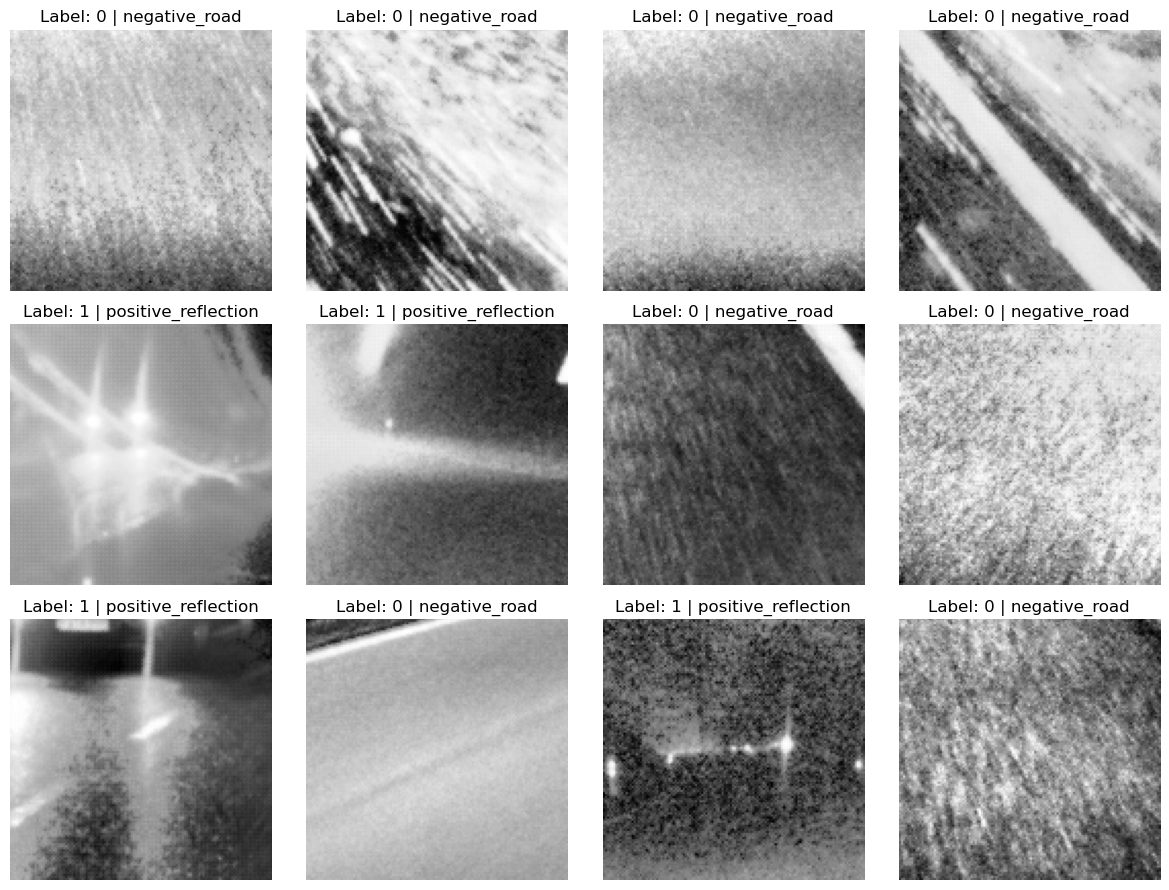

In [18]:
sample_df = patch_df.sample(12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    
    patch = cv2.imread(
        row["patch_path"],
        cv2.IMREAD_GRAYSCALE
    )
    
    ax.imshow(patch, cmap="gray")
    ax.set_title(
        f"Label: {row['label']} | {row['patch_type']}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Cell 12: Visualize positives only

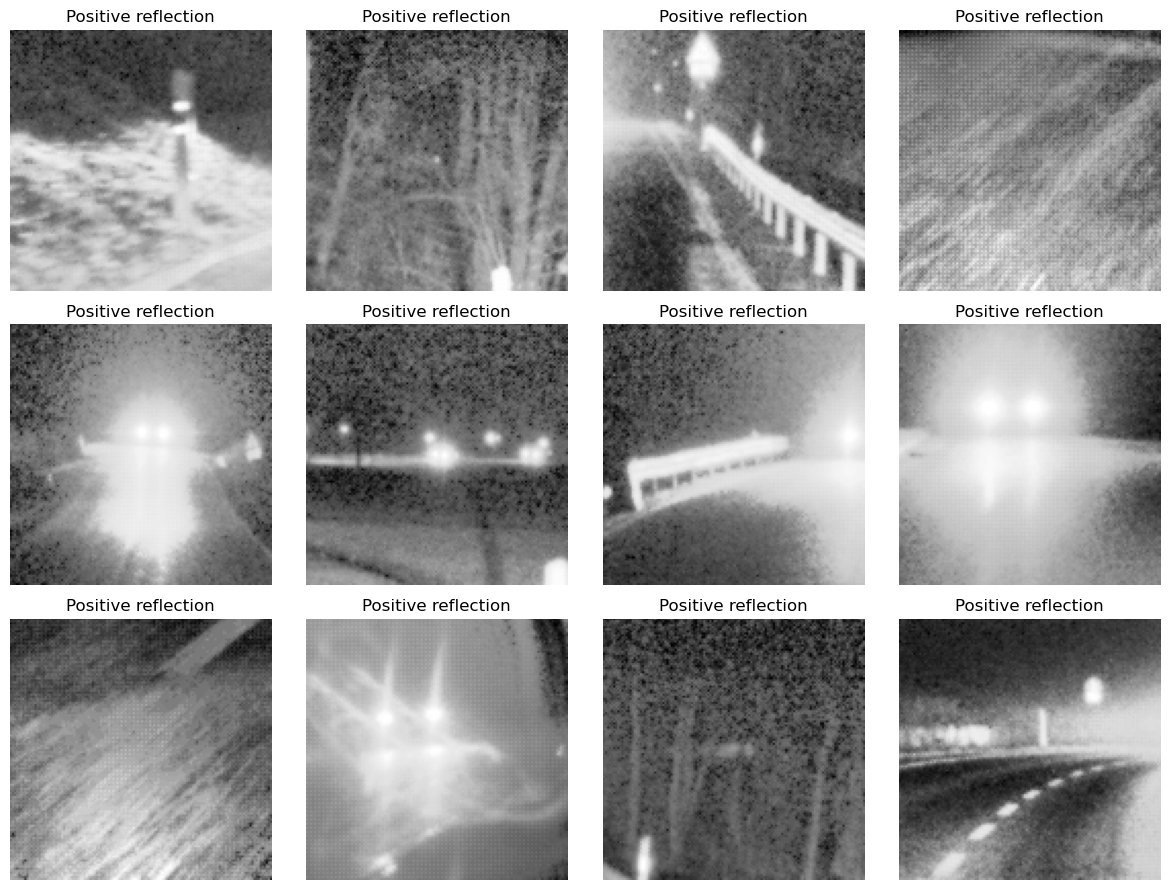

In [19]:
pos_df = patch_df[patch_df["label"] == 1]

sample_pos = pos_df.sample(
    min(12, len(pos_df)),
    random_state=7
)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.flatten(), sample_pos.iterrows()):
    
    patch = cv2.imread(
        row["patch_path"],
        cv2.IMREAD_GRAYSCALE
    )
    
    ax.imshow(patch, cmap="gray")
    ax.set_title("Positive reflection")
    ax.axis("off")

plt.tight_layout()
plt.show()

Cell 13: Visualize negatives only

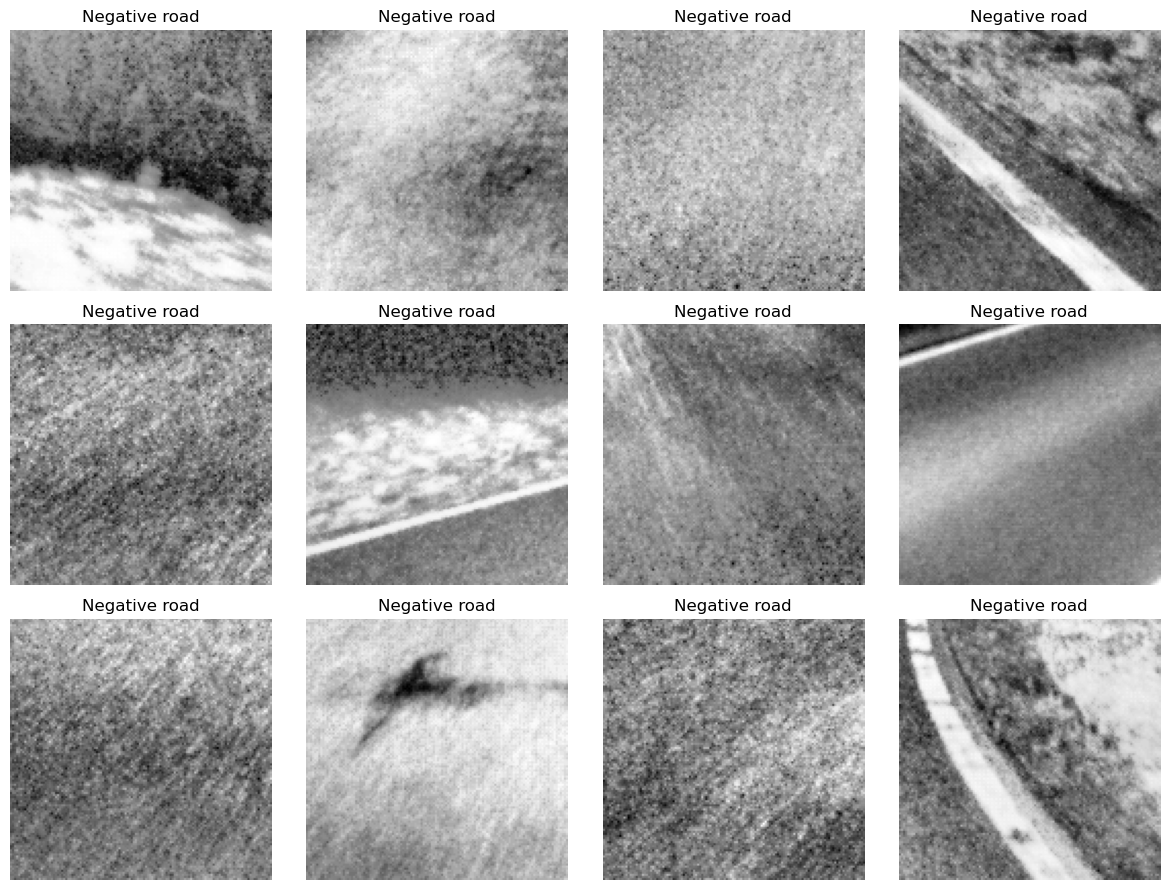

In [20]:
neg_df = patch_df[patch_df["label"] == 0]

sample_neg = neg_df.sample(
    min(12, len(neg_df)),
    random_state=9
)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.flatten(), sample_neg.iterrows()):
    
    patch = cv2.imread(
        row["patch_path"],
        cv2.IMREAD_GRAYSCALE
    )
    
    ax.imshow(patch, cmap="gray")
    ax.set_title("Negative road")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
patch_df["label"].value_counts()

label
0    64716
1    41836
Name: count, dtype: int64

Visualize Patches over OG image

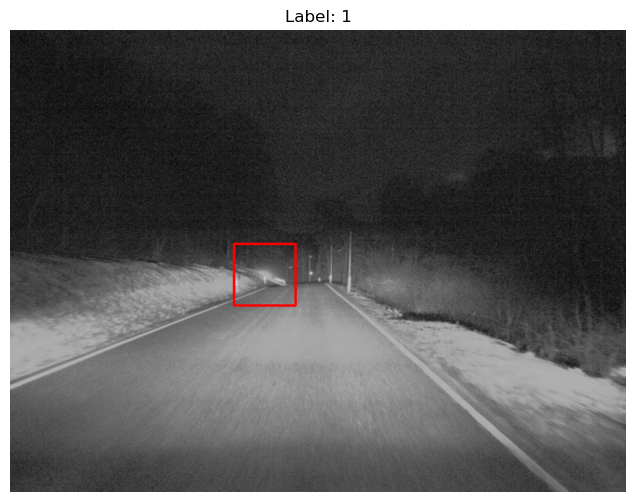

In [22]:
sample_row = patch_df.sample(1).iloc[0]

image = cv2.imread(
    sample_row["source_image_path"],
    cv2.IMREAD_GRAYSCALE
)

x = int(sample_row["center_x"])
y = int(sample_row["center_y"])

patch_size = PATCH_SIZE

half = patch_size // 2

x1 = x - half
y1 = y - half

rect_image = cv2.cvtColor(
    image,
    cv2.COLOR_GRAY2RGB
)

cv2.rectangle(
    rect_image,
    (x1, y1),
    (x1 + patch_size, y1 + patch_size),
    (255,0,0),
    3
)

plt.figure(figsize=(10,6))

plt.imshow(rect_image)

plt.title(
    f"Label: {sample_row['label']}"
)

plt.axis("off")

plt.show()